# Learn a Rotation-Invariant Radial Kernel via `f(r)`

This notebook parameterizes a 2D kernel by radial coefficients:

- `f0 = f(r=0)`
- `f1 = f(r=1)`
- `...`
- `fR = f(r=R)`

Then it optimizes the `f_i` values directly from data (instead of selecting from a predefined bank).

Default initialization uses `results/exp_022_mmr_nperFamily500_nComposition1250/composite_kernel.npy`,
but all paths are configurable so this can run with any compatible experiment/data folder.


In [12]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy.ndimage import rotate


from kernel_model.data import load_patches_from_folders, to_tensor_batch

# -----------------------------
# User config
# -----------------------------
EXP_DIR = Path("results/exp_022_mmr_nperFamily500_nComposition1250")
# EXP_DIR = Path("results/exp_022_mmr_nperFamily250_nComposition625")
# EXP_DIR = Path("results/exp_022_mmr_nperFamily50_nComposition125")
# EXP_DIR = Path("results/exp_022_mmr_nperFamily10_nComposition25")
KERNEL_FILENAME = "composite_kernel.npy"

# Set DATA_ROOT explicitly to use a different patch folder.
# If None: try EXP_DIR/config.json:data_root, else fallback to data/patches
DATA_ROOT = None

TRAIN_SPLIT = "train"
EVAL_SPLIT = "test"
RESIZE_PATCH = 128
MAX_PER_CLASS = None

# Optimize f_0 ... f_R_MAX (inclusive)
R_MAX = 10

# For exp_022, keep patch standardization OFF; enabling it drops AUC/ACC sharply.
RESPONSE_MODE = "abs_max"  # "mean_abs" or "abs_max"
STANDARDIZE_PATCHES = False

# Optimization hyperparameters
EPOCHS = 25
BATCH_SIZE = 128
LR_F = 1e-2
LR_HEAD = 1e-2
LAMBDA_SMOOTH = 1e-3  # smoothness penalty on neighboring f_i values
LAMBDA_ANCHOR = 5e-2  # keep f_i close to initialization to avoid collapse
WEIGHT_DECAY = 0.0

# Model-selection / threshold settings
SELECT_BY = "eval_acc"  # "eval_acc_tuned", "eval_acc", "eval_auc"
TUNE_THRESHOLD = True
THRESHOLD_GRID_SIZE = 181

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# DataLoader settings
NUM_WORKERS = 0
PIN_MEMORY = bool(DEVICE == "cuda")

OUT_DIR = EXP_DIR / "radial_fit_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using device: {DEVICE}")
print(f"Output dir: {OUT_DIR}")



Using device: cuda
Output dir: results/exp_022_mmr_nperFamily500_nComposition1250/radial_fit_results


In [13]:
def resolve_data_root(exp_dir: Path, data_root_override):
    if data_root_override is not None:
        return Path(data_root_override)
    cfg_path = exp_dir / "config.json"
    if cfg_path.exists():
        cfg = json.loads(cfg_path.read_text())
        return Path(cfg.get("data_root", "data/patches"))
    return Path("data/patches")


def load_split(root_dir: Path, split_name: str, resize_patch: int, max_per_class=None):
    return load_patches_from_folders(
        root_dir,
        max_per_class=max_per_class,
        resize=(resize_patch, resize_patch),
        splits=(split_name,),
    )


def integer_radius_bins(kernel_shape):
    h, w = kernel_shape
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    yy, xx = np.indices((h, w))
    r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    return np.floor(r).astype(np.int64)


def radial_profile_from_kernel(kernel2d: np.ndarray):
    r_bin = integer_radius_bins(kernel2d.shape)
    max_r = int(r_bin.max())
    radial_sum = np.bincount(r_bin.ravel(), weights=kernel2d.ravel(), minlength=max_r + 1)
    radial_count = np.bincount(r_bin.ravel(), minlength=max_r + 1)
    profile = radial_sum / np.maximum(radial_count, 1)
    return profile, r_bin


def build_radial_basis(radius_bins: np.ndarray, r_max: int):
    r_eff = min(int(r_max), int(radius_bins.max()))
    basis = np.stack([(radius_bins == i).astype(np.float32) for i in range(r_eff + 1)], axis=0)
    return basis, r_eff


def kernel_from_coeffs(coeffs: torch.Tensor, basis_t: torch.Tensor):
    # coeffs: (R+1,), basis_t: (R+1,H,W)
    return torch.sum(coeffs[:, None, None] * basis_t, dim=0)


def patch_standardize(x_t: torch.Tensor):
    mean = x_t.mean(dim=(2, 3), keepdim=True)
    std = x_t.std(dim=(2, 3), keepdim=True)
    std = torch.where(std < 1e-6, torch.ones_like(std), std)
    return (x_t - mean) / std


def make_xy_tensors(Xin_np: np.ndarray, Xout_np: np.ndarray, standardize: bool):
    X = np.concatenate([Xin_np, Xout_np], axis=0).astype(np.float32)
    y = np.concatenate([
        np.ones(len(Xin_np), dtype=np.float32),
        np.zeros(len(Xout_np), dtype=np.float32),
    ])

    # Keep tensors on CPU; move mini-batches to DEVICE inside the training loop.
    X_t = to_tensor_batch(X, torch.device("cpu"))
    if standardize:
        X_t = patch_standardize(X_t)
    y_t = torch.from_numpy(y)
    return X_t.contiguous(), y_t.contiguous()


def response_from_kernel(x_t: torch.Tensor, kernel2d_t: torch.Tensor, mode: str):
    out = F.conv2d(x_t, kernel2d_t[None, None, :, :], padding=kernel2d_t.shape[-1] // 2)
    if mode == "abs_max":
        return out.abs().amax(dim=(1, 2, 3))
    return out.abs().mean(dim=(1, 2, 3))


@torch.no_grad()
def predict_probs(
    x_t: torch.Tensor,
    coeffs: torch.Tensor,
    basis_t: torch.Tensor,
    w: torch.Tensor,
    b: torch.Tensor,
    mode: str,
    batch_size: int,
    device: str,
):
    dev = torch.device(device)
    k_t = kernel_from_coeffs(coeffs, basis_t)
    probs = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(dev, non_blocking=True)
        feat = response_from_kernel(xb, k_t, mode)
        logits = w * feat + b
        probs.append(torch.sigmoid(logits).detach().cpu().numpy())
    if not probs:
        return np.zeros((0,), dtype=np.float32)
    return np.concatenate(probs, axis=0)


def metrics_from_probs(y_true: np.ndarray, probs: np.ndarray, threshold: float = 0.5):
    if len(y_true) == 0:
        return {"acc": float("nan"), "auc": float("nan")}
    y_hat = (probs > float(threshold)).astype(np.int64)
    acc = accuracy_score(y_true, y_hat)
    auc = roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else float("nan")
    return {"acc": float(acc), "auc": float(auc)}


def best_threshold_by_accuracy(y_true: np.ndarray, probs: np.ndarray, grid_size: int = 181):
    if len(y_true) == 0:
        return 0.5, float("nan")
    grid = np.linspace(0.05, 0.95, int(grid_size), dtype=np.float32)
    preds = probs[None, :] > grid[:, None]
    accs = (preds == y_true[None, :]).mean(axis=1)
    best_idx = int(np.argmax(accs))
    return float(grid[best_idx]), float(accs[best_idx])


Kernel shape: (31, 31)
Requested R_MAX=10, effective max optimized radius=10
Initial coefficients:
  f00 = -2.329369e-03
  f01 = +1.467042e-03
  f02 = -5.052745e-04
  f03 = +9.676782e-05
  f04 = +1.560518e-04
  f05 = -8.108011e-05
  f06 = +2.599227e-04
  f07 = -1.852062e-04
  f08 = +2.350261e-04
  f09 = -1.194048e-04
  f10 = +8.814345e-05


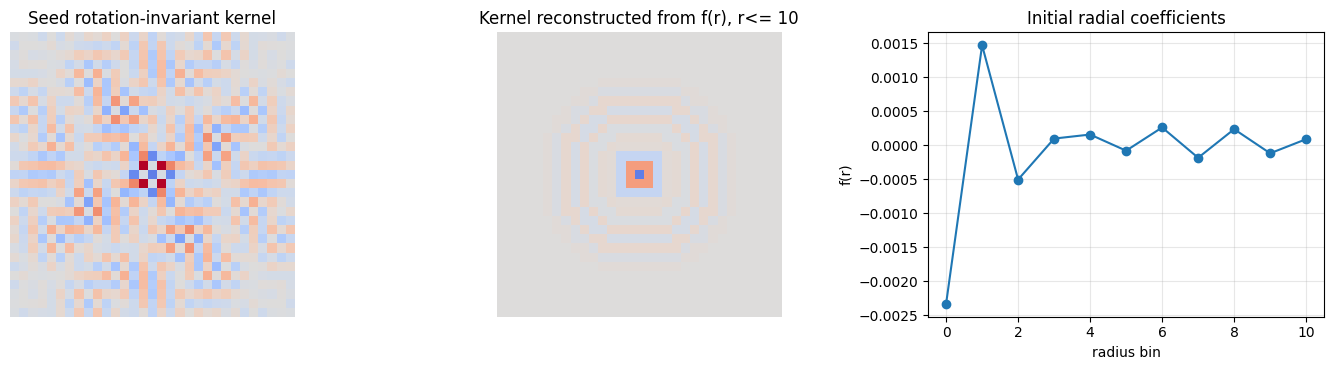

In [14]:
# -----------------------------
# Load base kernel and initialize radial coefficients f_i
# -----------------------------
kernel_path = EXP_DIR / KERNEL_FILENAME
if not kernel_path.exists():
    raise FileNotFoundError(f"Missing kernel file: {kernel_path}")

base_kernel = np.load(kernel_path).astype(np.float32)
if base_kernel.ndim != 2:
    raise ValueError(f"Expected 2D kernel, got shape={base_kernel.shape}")

# Build a rotation-invariant seed kernel via right-angle averaging
rotated = [np.rot90(base_kernel, k=k).copy() for k in range(4)]
# rotated = [
#     rotate(base_kernel, angle=angle, reshape=False, order=1)
#     for angle in range(0, 360, 10)
# ]
seed_kernel_ri = np.mean(np.stack(rotated, axis=0), axis=0).astype(np.float32)

radial_profile_full, radius_bins = radial_profile_from_kernel(seed_kernel_ri)
basis_np, r_eff = build_radial_basis(radius_bins, R_MAX)
radius_axis = np.arange(r_eff + 1)
f_init = radial_profile_full[: r_eff + 1].astype(np.float32)

print(f"Kernel shape: {seed_kernel_ri.shape}")
print(f"Requested R_MAX={R_MAX}, effective max optimized radius={r_eff}")
print("Initial coefficients:")
for i, v in enumerate(f_init):
    print(f"  f{i:02d} = {v:+.6e}")

seed_kernel_from_f = (f_init[:, None, None] * basis_np).sum(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

v = max(float(np.max(np.abs(seed_kernel_ri))), float(np.max(np.abs(seed_kernel_from_f)))) + 1e-12
axes[0].imshow(seed_kernel_ri, cmap="coolwarm", vmin=-v, vmax=v)
axes[0].set_title("Seed rotation-invariant kernel")
axes[0].axis("off")

axes[1].imshow(seed_kernel_from_f, cmap="coolwarm", vmin=-v, vmax=v)
axes[1].set_title(f"Kernel reconstructed from f(r), r<= {r_eff}")
axes[1].axis("off")

axes[2].plot(radius_axis, f_init, marker="o", linewidth=1.5)
axes[2].set_xlabel("radius bin")
axes[2].set_ylabel("f(r)")
axes[2].set_title("Initial radial coefficients")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [20]:
# -----------------------------
# Seed kernel (seed_kernel_ri) baseline accuracy
# -----------------------------
from sklearn.linear_model import LogisticRegression

# Ensure train/eval tensors are available (safe to run before/after data-loading cell).
if not all(name in globals() for name in ["X_train_t", "y_train_t", "X_eval_t", "y_eval_t", "y_train_np", "y_eval_np"]):
    data_root = resolve_data_root(EXP_DIR, DATA_ROOT)

    Xin_train, Xout_train = load_split(data_root, TRAIN_SPLIT, RESIZE_PATCH, MAX_PER_CLASS)
    try:
        Xin_eval, Xout_eval = load_split(data_root, EVAL_SPLIT, RESIZE_PATCH, MAX_PER_CLASS)
        eval_split_used = EVAL_SPLIT
    except FileNotFoundError:
        Xin_eval, Xout_eval = Xin_train, Xout_train
        eval_split_used = TRAIN_SPLIT

    X_train_t, y_train_t = make_xy_tensors(Xin_train, Xout_train, STANDARDIZE_PATCHES)
    X_eval_t, y_eval_t = make_xy_tensors(Xin_eval, Xout_eval, STANDARDIZE_PATCHES)
    y_train_np = y_train_t.numpy()
    y_eval_np = y_eval_t.numpy()


@torch.no_grad()
def extract_seed_features(x_t: torch.Tensor, kernel_np: np.ndarray, batch_size: int):
    dev = torch.device(DEVICE)
    k_t = torch.from_numpy(kernel_np.astype(np.float32)).to(dev)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(dev, non_blocking=True)
        f = response_from_kernel(xb, k_t, RESPONSE_MODE)
        feats.append(f.detach().cpu().numpy().reshape(-1))
    return np.concatenate(feats, axis=0) if feats else np.zeros((0,), dtype=np.float32)


# 1) Extract scalar responses from seed kernel
seed_feat_train = extract_seed_features(X_train_t, seed_kernel_ri, BATCH_SIZE)
seed_feat_eval = extract_seed_features(X_eval_t, seed_kernel_ri, BATCH_SIZE)

# 2) Z-score using train stats
mu = float(seed_feat_train.mean()) if seed_feat_train.size else 0.0
sd = float(seed_feat_train.std()) if seed_feat_train.size else 1.0
if sd < 1e-8:
    sd = 1.0

Xtr = ((seed_feat_train - mu) / sd).reshape(-1, 1)
Xev = ((seed_feat_eval - mu) / sd).reshape(-1, 1)
ytr = y_train_np.astype(int)
yev = y_eval_np.astype(int)

# 3) Fit a 1D logistic head on train responses
clf_seed = LogisticRegression(max_iter=1000)
clf_seed.fit(Xtr, ytr)

p_train = clf_seed.predict_proba(Xtr)[:, 1]
p_eval = clf_seed.predict_proba(Xev)[:, 1]

thr_star, train_acc_tuned = best_threshold_by_accuracy(ytr, p_train, THRESHOLD_GRID_SIZE)
m_eval_05 = metrics_from_probs(yev, p_eval, threshold=0.5)
m_eval_tuned = metrics_from_probs(yev, p_eval, threshold=thr_star)

print('Seed-kernel baseline metrics (seed_kernel_ri):')
print(f"  eval_split={globals().get('eval_split_used', EVAL_SPLIT)} N={len(yev)}")
print(f"  AUC={m_eval_05['auc']:.6f}")
print(f"  ACC@0.5={m_eval_05['acc']:.6f}")
print(f"  ACC@thr*={m_eval_tuned['acc']:.6f} (thr*={thr_star:.3f}, train_acc@thr*={train_acc_tuned:.6f})")


Seed-kernel baseline metrics (seed_kernel_ri):
  eval_split=test N=1750
  AUC=0.875518
  ACC@0.5=0.793143
  ACC@thr*=0.793143 (thr*=0.500, train_acc@thr*=0.821327)


In [15]:
# -----------------------------
# Load train/eval patches (works for any compatible root folder)
# -----------------------------
data_root = resolve_data_root(EXP_DIR, DATA_ROOT)
print(f"Data root: {data_root}")

Xin_train, Xout_train = load_split(data_root, TRAIN_SPLIT, RESIZE_PATCH, MAX_PER_CLASS)
print(f"Train split loaded: Xin={Xin_train.shape}, Xout={Xout_train.shape}")

try:
    Xin_eval, Xout_eval = load_split(data_root, EVAL_SPLIT, RESIZE_PATCH, MAX_PER_CLASS)
    eval_split_used = EVAL_SPLIT
except FileNotFoundError:
    Xin_eval, Xout_eval = Xin_train, Xout_train
    eval_split_used = TRAIN_SPLIT
    print(f"Warning: split '{EVAL_SPLIT}' not found; falling back to '{TRAIN_SPLIT}' for evaluation.")

print(f"Eval split used: {eval_split_used}")
print(f"Eval split loaded: Xin={Xin_eval.shape}, Xout={Xout_eval.shape}")

X_train_t, y_train_t = make_xy_tensors(Xin_train, Xout_train, STANDARDIZE_PATCHES)
X_eval_t, y_eval_t = make_xy_tensors(Xin_eval, Xout_eval, STANDARDIZE_PATCHES)

y_train_np = y_train_t.numpy()
y_eval_np = y_eval_t.numpy()

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=bool(NUM_WORKERS > 0),
)

basis_t = torch.from_numpy(basis_np).to(torch.device(DEVICE))



Data root: data/patches
Train split loaded: Xin=(2960, 128, 128), Xout=(3370, 128, 128)
Eval split used: test
Eval split loaded: Xin=(960, 128, 128), Xout=(790, 128, 128)


In [16]:
# -----------------------------
# Optimize f_i jointly with a 1D logistic head
# -----------------------------
coeffs = torch.nn.Parameter(torch.tensor(f_init, device=torch.device(DEVICE)))
head_w = torch.nn.Parameter(torch.tensor(1.0, device=torch.device(DEVICE)))
head_b = torch.nn.Parameter(torch.tensor(0.0, device=torch.device(DEVICE)))

optimizer = torch.optim.Adam(
    [
        {"params": [coeffs], "lr": LR_F, "weight_decay": WEIGHT_DECAY},
        {"params": [head_w, head_b], "lr": LR_HEAD},
    ]
)
loss_fn = torch.nn.BCEWithLogitsLoss()

coeffs_init_ref = torch.tensor(f_init, device=torch.device(DEVICE))
best_selection_value = -float("inf")
best_state = None

history = []

for epoch in range(1, EPOCHS + 1):
    running_loss = 0.0
    n_seen = 0

    for xb, yb in train_loader:
        xb = xb.to(torch.device(DEVICE), non_blocking=True)
        yb = yb.to(torch.device(DEVICE), non_blocking=True)

        k_t = kernel_from_coeffs(coeffs, basis_t)
        feat = response_from_kernel(xb, k_t, RESPONSE_MODE)
        logits = head_w * feat + head_b

        loss_cls = loss_fn(logits, yb)
        if coeffs.numel() > 1:
            loss_smooth = torch.mean((coeffs[1:] - coeffs[:-1]) ** 2)
        else:
            loss_smooth = torch.tensor(0.0, device=coeffs.device)

        loss_anchor = torch.mean((coeffs - coeffs_init_ref) ** 2)
        loss = loss_cls + LAMBDA_SMOOTH * loss_smooth + LAMBDA_ANCHOR * loss_anchor

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_n = xb.shape[0]
        running_loss += float(loss.item()) * batch_n
        n_seen += batch_n

    avg_loss = running_loss / max(n_seen, 1)

    train_probs = predict_probs(X_train_t, coeffs, basis_t, head_w, head_b, RESPONSE_MODE, BATCH_SIZE, DEVICE)
    eval_probs = predict_probs(X_eval_t, coeffs, basis_t, head_w, head_b, RESPONSE_MODE, BATCH_SIZE, DEVICE)

    # Fixed-threshold metrics
    train_m = metrics_from_probs(y_train_np, train_probs, threshold=0.5)
    eval_m = metrics_from_probs(y_eval_np, eval_probs, threshold=0.5)

    # Threshold-tuned metrics (threshold picked on train, applied on eval)
    if TUNE_THRESHOLD:
        threshold_star, train_acc_tuned = best_threshold_by_accuracy(y_train_np, train_probs, THRESHOLD_GRID_SIZE)
    else:
        threshold_star, train_acc_tuned = 0.5, train_m["acc"]
    eval_m_tuned = metrics_from_probs(y_eval_np, eval_probs, threshold=threshold_star)

    row = {
        "epoch": epoch,
        "loss": avg_loss,
        "threshold_star": float(threshold_star),
        "train_auc": train_m["auc"],
        "train_acc": train_m["acc"],
        "train_acc_tuned": float(train_acc_tuned),
        "eval_auc": eval_m["auc"],
        "eval_acc": eval_m["acc"],
        "eval_acc_tuned": eval_m_tuned["acc"],
    }
    history.append(row)

    if SELECT_BY == "eval_auc":
        selection_value = eval_m["auc"]
    elif SELECT_BY == "eval_acc":
        selection_value = eval_m["acc"]
    else:
        selection_value = eval_m_tuned["acc"]

    if (
        selection_value > best_selection_value
        or (
            abs(selection_value - best_selection_value) <= 1e-12
            and eval_m["auc"] > (best_state["eval_auc"] if best_state is not None else -float("inf"))
        )
    ):
        best_selection_value = selection_value
        best_state = {
            "epoch": epoch,
            "coeffs": coeffs.detach().cpu().clone(),
            "head_w": head_w.detach().cpu().clone(),
            "head_b": head_b.detach().cpu().clone(),
            "threshold_star": float(threshold_star),
            "eval_auc": float(eval_m["auc"]),
            "eval_acc": float(eval_m["acc"]),
            "eval_acc_tuned": float(eval_m_tuned["acc"]),
            "selection_value": float(selection_value),
        }

    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        print(
            f"epoch={epoch:03d} "
            f"loss={avg_loss:.6f} "
            f"train_auc={train_m['auc']:.6f} train_acc={train_m['acc']:.6f} "
            f"eval_auc={eval_m['auc']:.6f} eval_acc={eval_m['acc']:.6f} "
            f"eval_acc_tuned={eval_m_tuned['acc']:.6f} thr*={threshold_star:.3f}"
        )

if best_state is not None:
    coeffs.data.copy_(best_state["coeffs"].to(coeffs.device))
    head_w.data.copy_(best_state["head_w"].to(head_w.device))
    head_b.data.copy_(best_state["head_b"].to(head_b.device))
    threshold_star = float(best_state["threshold_star"])
    print(
        f"Restored best checkpoint from epoch {best_state['epoch']:03d} by {SELECT_BY}: "
        f"eval_auc={best_state['eval_auc']:.6f}, "
        f"eval_acc={best_state['eval_acc']:.6f}, "
        f"eval_acc_tuned={best_state['eval_acc_tuned']:.6f}, "
        f"thr*={best_state['threshold_star']:.3f}"
    )


epoch=001 loss=0.718079 train_auc=0.898773 train_acc=0.527330 eval_auc=0.886054 eval_acc=0.597143 eval_acc_tuned=0.820571 thr*=0.535
epoch=005 loss=0.633728 train_auc=0.907211 train_acc=0.829858 eval_auc=0.898724 eval_acc=0.782286 eval_acc_tuned=0.840000 thr*=0.490
epoch=010 loss=0.585703 train_auc=0.906352 train_acc=0.758136 eval_auc=0.896886 eval_acc=0.784571 eval_acc_tuned=0.846286 thr*=0.555
epoch=015 loss=0.544566 train_auc=0.906770 train_acc=0.839968 eval_auc=0.897656 eval_acc=0.816000 eval_acc_tuned=0.842857 thr*=0.490
epoch=020 loss=0.520993 train_auc=0.906786 train_acc=0.838389 eval_auc=0.897727 eval_acc=0.849714 eval_acc_tuned=0.844571 thr*=0.510
epoch=025 loss=0.498053 train_auc=0.906785 train_acc=0.818167 eval_auc=0.897712 eval_acc=0.830286 eval_acc_tuned=0.842857 thr*=0.555
Restored best checkpoint from epoch 013 by eval_acc: eval_auc=0.897333, eval_acc=0.852000, eval_acc_tuned=0.829143, thr*=0.505


Learned coefficients (init -> optimized):
  f00: -2.329369e-03 -> -7.133113e-03
  f01: +1.467042e-03 -> -2.848434e-03
  f02: -5.052745e-04 -> -3.788645e-03
  f03: +9.676782e-05 -> -2.460491e-03
  f04: +1.560518e-04 -> +5.410645e-04
  f05: -8.108011e-05 -> +3.562650e-03
  f06: +2.599227e-04 -> +6.398307e-03
  f07: -1.852062e-04 -> +1.258613e-02
  f08: +2.350261e-04 -> +3.293511e-02
  f09: -1.194048e-04 -> +5.429878e-02
  f10: +8.814345e-05 -> +8.669753e-02


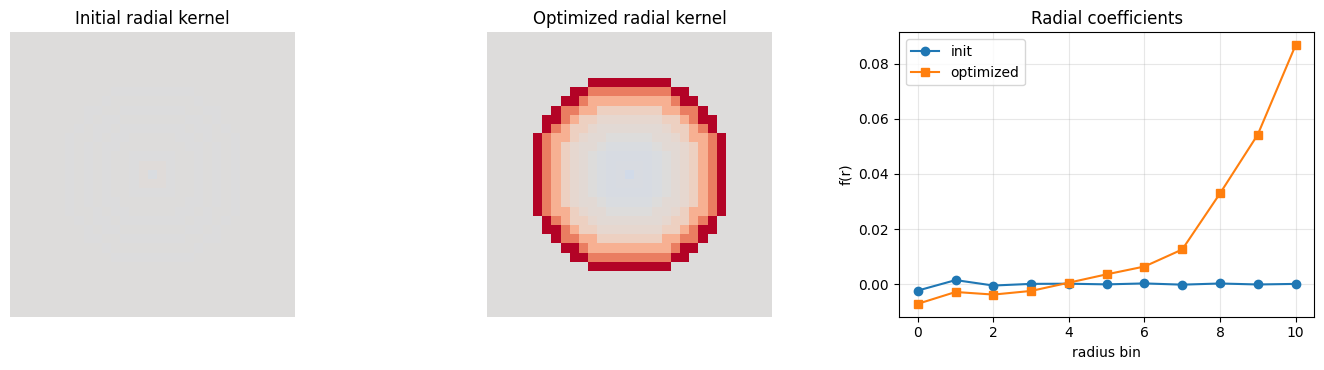

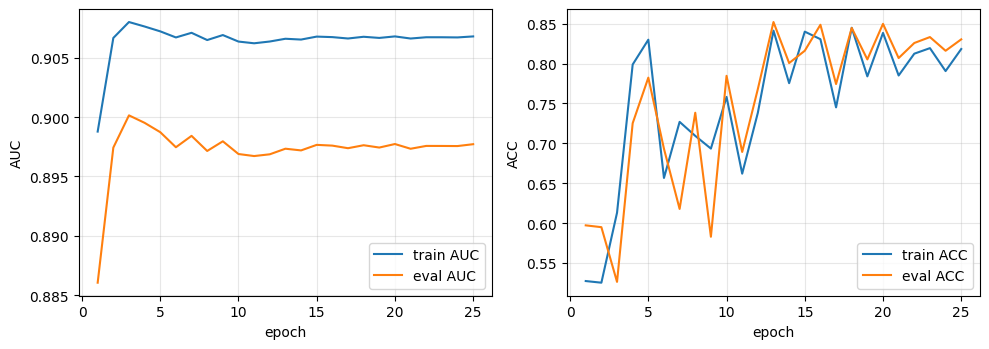

In [17]:
# -----------------------------
# Inspect learned coefficients and kernels
# -----------------------------
f_opt = coeffs.detach().cpu().numpy().astype(np.float32)
k_opt = (f_opt[:, None, None] * basis_np).sum(axis=0).astype(np.float32)

print("Learned coefficients (init -> optimized):")
for i, (a, b) in enumerate(zip(f_init, f_opt)):
    print(f"  f{i:02d}: {a:+.6e} -> {b:+.6e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

v = max(float(np.max(np.abs(seed_kernel_from_f))), float(np.max(np.abs(k_opt)))) + 1e-12
axes[0].imshow(seed_kernel_from_f, cmap="coolwarm", vmin=-v, vmax=v)
axes[0].set_title("Initial radial kernel")
axes[0].axis("off")

axes[1].imshow(k_opt, cmap="coolwarm", vmin=-v, vmax=v)
axes[1].set_title("Optimized radial kernel")
axes[1].axis("off")

axes[2].plot(radius_axis, f_init, marker="o", linewidth=1.5, label="init")
axes[2].plot(radius_axis, f_opt, marker="s", linewidth=1.5, label="optimized")
axes[2].set_xlabel("radius bin")
axes[2].set_ylabel("f(r)")
axes[2].set_title("Radial coefficients")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# Training curves
epochs_arr = np.array([h["epoch"] for h in history])
train_auc_arr = np.array([h["train_auc"] for h in history])
eval_auc_arr = np.array([h["eval_auc"] for h in history])
train_acc_arr = np.array([h["train_acc"] for h in history])
eval_acc_arr = np.array([h["eval_acc"] for h in history])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(epochs_arr, train_auc_arr, label="train AUC")
axes[0].plot(epochs_arr, eval_auc_arr, label="eval AUC")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("AUC")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_arr, train_acc_arr, label="train ACC")
axes[1].plot(epochs_arr, eval_acc_arr, label="eval ACC")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("ACC")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


In [18]:
# -----------------------------
# Optional: right-angle rotation check on eval split
# -----------------------------
def rotate_patches_90(arr: np.ndarray, angle_deg: int):
    angle_deg = int(angle_deg) % 360
    if angle_deg % 90 != 0:
        raise ValueError("This helper supports only multiples of 90 degrees.")
    if angle_deg == 0:
        return arr
    k = angle_deg // 90
    return np.rot90(arr, k=k, axes=(1, 2)).copy()

angles = [0, 90, 180, 270]
rows = []
for ang in angles:
    Xin_r = rotate_patches_90(Xin_eval, ang)
    Xout_r = rotate_patches_90(Xout_eval, ang)
    X_r_t, y_r_t = make_xy_tensors(Xin_r, Xout_r, STANDARDIZE_PATCHES)
    probs_r = predict_probs(X_r_t, coeffs, basis_t, head_w, head_b, RESPONSE_MODE, BATCH_SIZE, DEVICE)
    m05 = metrics_from_probs(y_r_t.numpy(), probs_r, threshold=0.5)
    mtuned = metrics_from_probs(y_r_t.numpy(), probs_r, threshold=float(threshold_star))
    rows.append((ang, m05["auc"], m05["acc"], mtuned["acc"], len(y_r_t)))

print(f"Rotation check on eval split '{eval_split_used}':")
print(f"Using tuned threshold: {threshold_star:.3f}")
for ang, auc, acc05, acctuned, n in rows:
    print(f"  rot {ang:3d}: AUC={auc:.6f} ACC@0.5={acc05:.6f} ACC@thr*={acctuned:.6f} N={n}")


Rotation check on eval split 'test':
Using tuned threshold: 0.505
  rot   0: AUC=0.897333 ACC@0.5=0.852000 ACC@thr*=0.829143 N=1750
  rot  90: AUC=0.897333 ACC@0.5=0.852000 ACC@thr*=0.829143 N=1750
  rot 180: AUC=0.897333 ACC@0.5=0.852000 ACC@thr*=0.829143 N=1750
  rot 270: AUC=0.897332 ACC@0.5=0.852000 ACC@thr*=0.829143 N=1750


Selected 3 image(s) from data/TIFF Images/Normal
Selected 3 image(s) from data/TIFF Images/malignantAnnotation
Running inference on 6 image(s) with stride=32, patch_size=128
Kernel mode: optimized; threshold=0.505


/tmp/ipykernel_4122735/1179115924.py:271: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


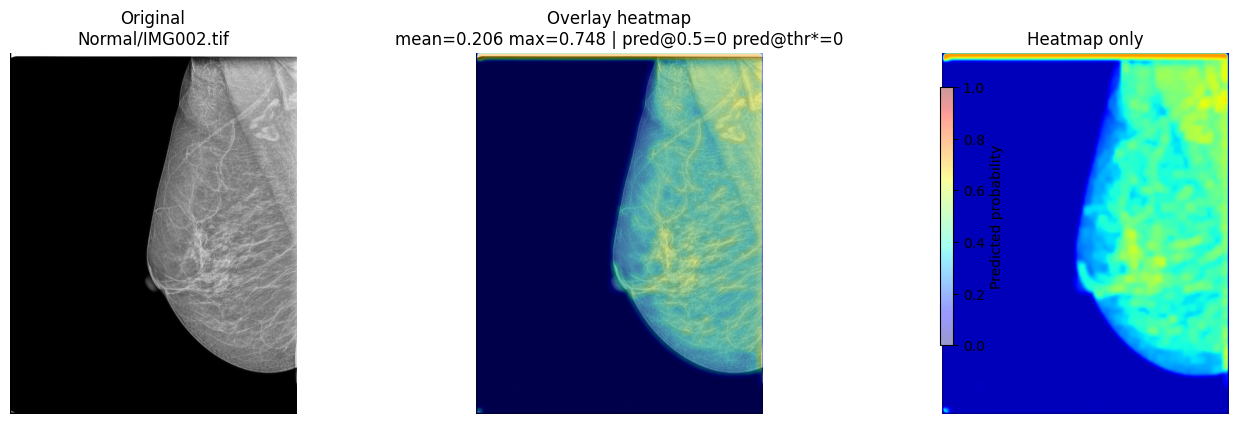

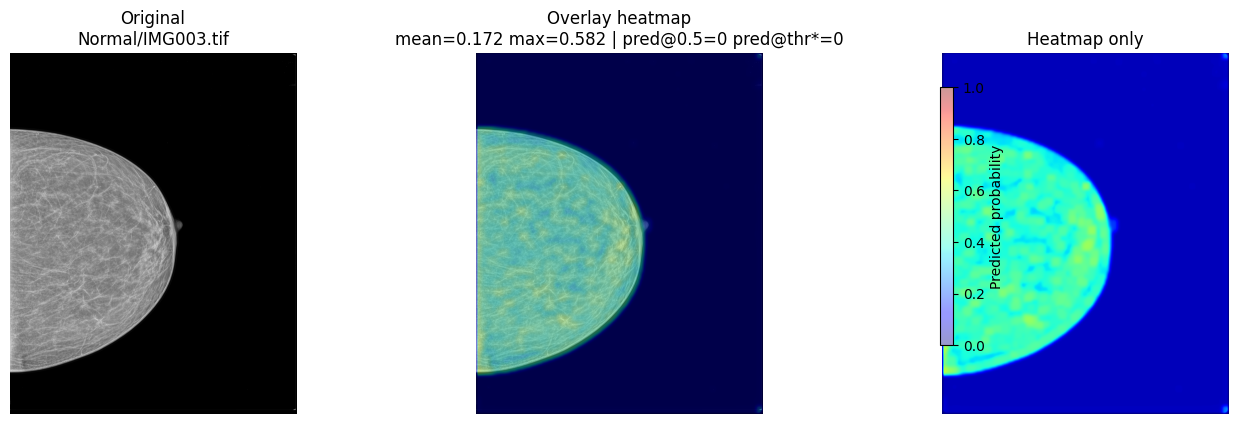

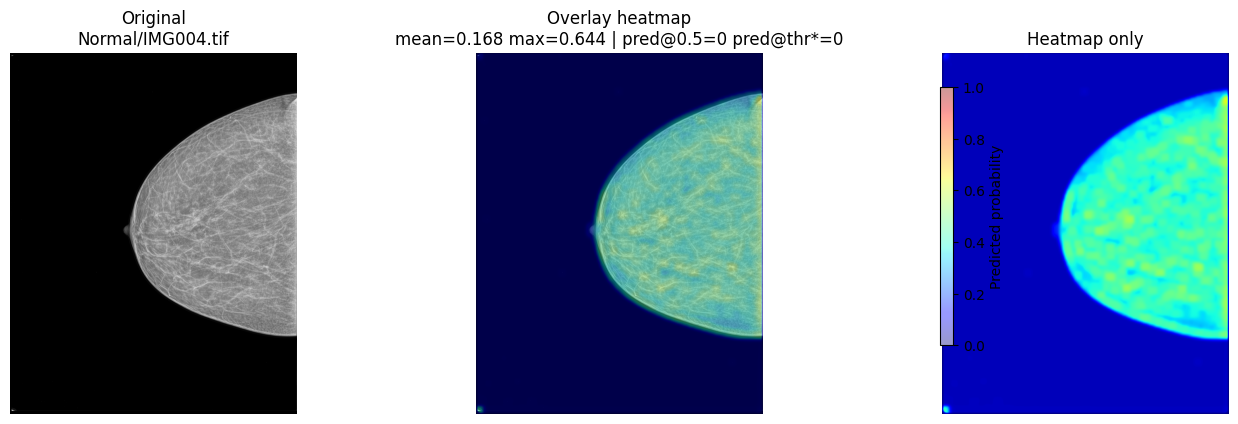

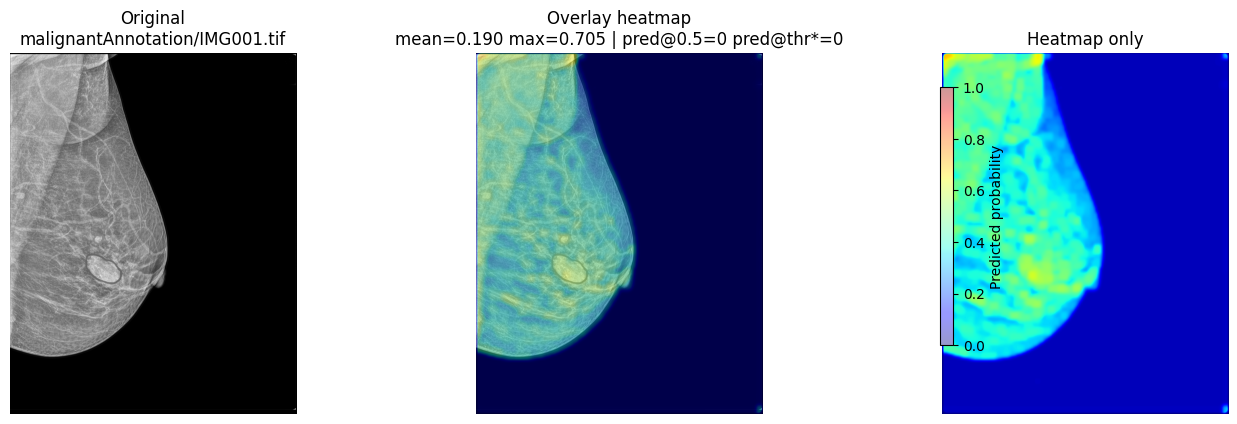

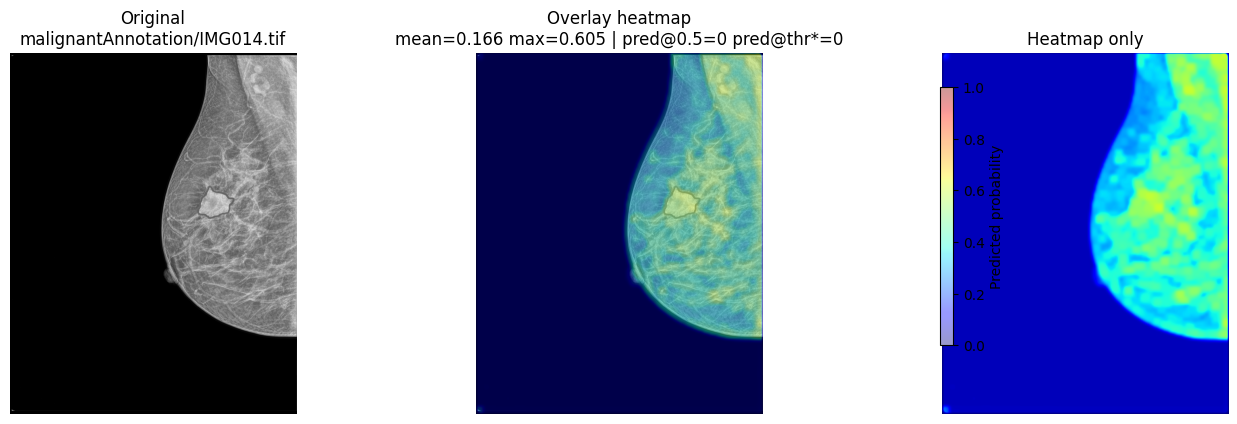

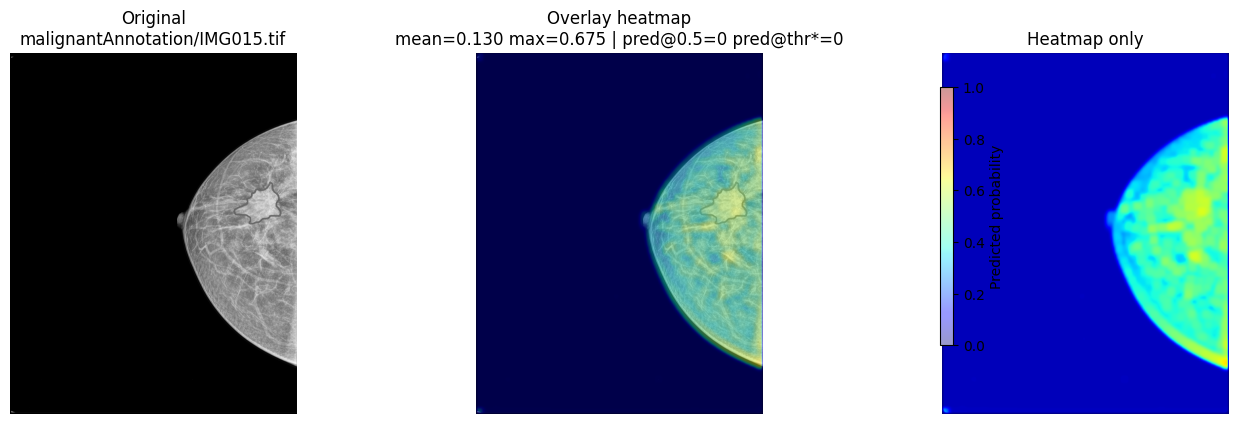

In [19]:
# -----------------------------
# Full-image inference + heatmaps (structured-style) on Normal + malignantAnnotation
# -----------------------------
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.linear_model import LogisticRegression

# ---- user inputs ----
normal_dir = Path("data/TIFF Images/Normal")
ann_dir = Path("data/TIFF Images/malignantAnnotation")
images_per_folder = 3
# Use a finer stride for higher-resolution heatmaps.
# Set explicitly (e.g., 16) for even more detail.
stride = None  # None -> uses patch_size // 4
show = True
save_figs = False
INFER_BATCH_SIZE = 128
KERNEL_FOR_INFERENCE = "optimized"  # "seed_ri" or "optimized"

# Heatmap blending controls to reduce blocky/square artifacts.
BLEND_MODE = "gaussian"  # "gaussian" or "uniform"
GAUSSIAN_SIGMA_RATIO = 0.20
OVERLAY_INTERPOLATION = "bilinear"

infer_out_dir = OUT_DIR / "full_image_inference"
infer_out_dir.mkdir(parents=True, exist_ok=True)

patch_size = int(RESIZE_PATCH)
if stride is None:
    stride = max(1, patch_size // 4)


def _grid_starts(length: int, patch: int, step: int):
    if length < patch:
        return []
    starts = list(range(0, length - patch + 1, step))
    if starts and starts[-1] != length - patch:
        starts.append(length - patch)
    return starts


def _collect_image_paths(folder: Path, n: int):
    files = sorted([p for p in folder.glob("*.tif")])
    if len(files) == 0:
        print(f"Warning: no tif files found in {folder}")
        return []
    chosen = files[:n]
    print(f"Selected {len(chosen)} image(s) from {folder}")
    return chosen


def _make_patch_blend_weights(patch: int, mode: str = "gaussian", sigma_ratio: float = 0.20):
    if mode == "uniform":
        return np.ones((patch, patch), dtype=np.float32)

    yy, xx = np.mgrid[0:patch, 0:patch].astype(np.float32)
    c = (patch - 1) / 2.0
    sigma = max(1.0, float(patch) * float(sigma_ratio))
    w = np.exp(-((yy - c) ** 2 + (xx - c) ** 2) / (2.0 * sigma * sigma)).astype(np.float32)
    w /= max(float(w.max()), 1e-8)
    return w


@torch.no_grad()
def _extract_scalar_features_for_kernel(x_t: torch.Tensor, kernel_np: np.ndarray, batch_size: int):
    dev = torch.device(DEVICE)
    k_t = torch.from_numpy(kernel_np.astype(np.float32)).to(dev)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(dev, non_blocking=True)
        feat = response_from_kernel(xb, k_t, RESPONSE_MODE)
        feats.append(feat.detach().cpu().numpy().reshape(-1))
    return np.concatenate(feats, axis=0) if feats else np.zeros((0,), dtype=np.float32)


def _fit_seed_head_if_needed():
    # Reuse if already available
    if "seed_head_params" in globals() and seed_head_params is not None:
        return seed_head_params

    print("Fitting calibration head for seed kernel (seed_kernel_ri)...")
    seed_feats_train = _extract_scalar_features_for_kernel(X_train_t, seed_kernel_ri, BATCH_SIZE)

    mu = float(seed_feats_train.mean()) if seed_feats_train.size else 0.0
    sd = float(seed_feats_train.std()) if seed_feats_train.size else 1.0
    if sd < 1e-8:
        sd = 1.0

    Xtr = ((seed_feats_train - mu) / sd).reshape(-1, 1)
    ytr = y_train_np.astype(int)

    clf_seed = LogisticRegression(max_iter=1000)
    clf_seed.fit(Xtr, ytr)

    p_train = clf_seed.predict_proba(Xtr)[:, 1]
    thr_seed, train_acc_tuned = best_threshold_by_accuracy(ytr, p_train, THRESHOLD_GRID_SIZE)
    train_auc = roc_auc_score(ytr, p_train) if len(np.unique(ytr)) > 1 else float("nan")

    # Optional eval sanity metrics
    seed_feats_eval = _extract_scalar_features_for_kernel(X_eval_t, seed_kernel_ri, BATCH_SIZE)
    Xev = ((seed_feats_eval - mu) / sd).reshape(-1, 1)
    yev = y_eval_np.astype(int)
    p_eval = clf_seed.predict_proba(Xev)[:, 1]
    eval_auc = roc_auc_score(yev, p_eval) if len(np.unique(yev)) > 1 else float("nan")
    eval_acc_05 = accuracy_score(yev, (p_eval > 0.5).astype(int))
    eval_acc_tuned = accuracy_score(yev, (p_eval > thr_seed).astype(int))

    params = {
        "w": float(clf_seed.coef_[0, 0]),
        "b": float(clf_seed.intercept_[0]),
        "mu": mu,
        "sd": sd,
        "thr": float(thr_seed),
        "train_auc": float(train_auc),
        "train_acc_tuned": float(train_acc_tuned),
        "eval_auc": float(eval_auc),
        "eval_acc_05": float(eval_acc_05),
        "eval_acc_tuned": float(eval_acc_tuned),
    }

    print(
        "Seed head fitted: "
        f"w={params['w']:+.4f}, b={params['b']:+.4f}, mu={params['mu']:.6f}, sd={params['sd']:.6f}, "
        f"thr={params['thr']:.3f}, eval_auc={params['eval_auc']:.6f}, eval_acc@0.5={params['eval_acc_05']:.6f}, "
        f"eval_acc@thr={params['eval_acc_tuned']:.6f}"
    )

    return params


@torch.no_grad()
def infer_heatmap_batched(img_arr: np.ndarray, batch_size: int = 64):
    H, W = img_arr.shape
    ys = _grid_starts(H, patch_size, stride)
    xs = _grid_starts(W, patch_size, stride)
    if not ys or not xs:
        raise ValueError(f"Image is smaller than patch size: {img_arr.shape} vs {patch_size}")

    coords = [(y, x) for y in ys for x in xs]

    heatmap = np.zeros((H, W), dtype=np.float32)
    count = np.zeros((H, W), dtype=np.float32)
    probs_all = []

    patch_weights = _make_patch_blend_weights(
        patch_size,
        mode=BLEND_MODE,
        sigma_ratio=GAUSSIAN_SIGMA_RATIO,
    )

    dev = torch.device(DEVICE)
    use_seed = (KERNEL_FOR_INFERENCE == "seed_ri")

    if use_seed:
        head = _fit_seed_head_if_needed()
        k_np = seed_kernel_ri.astype(np.float32)
        k_t = torch.from_numpy(k_np).to(dev)
        mu_t = torch.tensor(head["mu"], dtype=torch.float32, device=dev)
        sd_t = torch.tensor(head["sd"], dtype=torch.float32, device=dev)
        w_t = torch.tensor(head["w"], dtype=torch.float32, device=dev)
        b_t = torch.tensor(head["b"], dtype=torch.float32, device=dev)
    else:
        k_np = kernel_from_coeffs(coeffs, basis_t).detach().cpu().numpy().astype(np.float32)
        k_t = torch.from_numpy(k_np).to(dev)

    for i in range(0, len(coords), batch_size):
        batch_coords = coords[i : i + batch_size]
        patches = np.stack(
            [img_arr[y : y + patch_size, x : x + patch_size] for (y, x) in batch_coords],
            axis=0,
        ).astype(np.float32)

        x_t = to_tensor_batch(patches, torch.device("cpu"))
        if STANDARDIZE_PATCHES:
            x_t = patch_standardize(x_t)

        xb = x_t.to(dev, non_blocking=True)
        feat = response_from_kernel(xb, k_t, RESPONSE_MODE)

        if use_seed:
            feat_z = (feat - mu_t) / sd_t
            logits = w_t * feat_z + b_t
        else:
            logits = head_w * feat + head_b

        probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
        probs_all.append(probs)

        for (y, x), p in zip(batch_coords, probs):
            heatmap[y : y + patch_size, x : x + patch_size] += float(p) * patch_weights
            count[y : y + patch_size, x : x + patch_size] += patch_weights

    probs_all = np.concatenate(probs_all, axis=0) if probs_all else np.zeros((0,), dtype=np.float32)
    heatmap = heatmap / np.maximum(count, 1.0)
    return heatmap, probs_all


def _load_gray_image(path: Path):
    return np.array(Image.open(path).convert("L"), dtype=np.float32) / 255.0


# Fit seed head once if needed
seed_head_params = None
if KERNEL_FOR_INFERENCE == "seed_ri":
    seed_head_params = _fit_seed_head_if_needed()

selected_paths = []
selected_paths.extend(_collect_image_paths(normal_dir, images_per_folder))
selected_paths.extend(_collect_image_paths(ann_dir, images_per_folder))

if len(selected_paths) == 0:
    raise RuntimeError("No inference images found. Check folder paths.")

if KERNEL_FOR_INFERENCE == "seed_ri":
    threshold_for_pred = float(seed_head_params["thr"])
else:
    threshold_for_pred = float(globals().get("threshold_star", 0.5))

print(f"Running inference on {len(selected_paths)} image(s) with stride={stride}, patch_size={patch_size}")
print(f"Kernel mode: {KERNEL_FOR_INFERENCE}; threshold={threshold_for_pred:.3f}")

for img_path in selected_paths:
    img_arr = _load_gray_image(img_path)

    # Safety: upsize tiny images so at least one patch exists.
    if img_arr.shape[0] < patch_size or img_arr.shape[1] < patch_size:
        new_h = max(img_arr.shape[0], patch_size)
        new_w = max(img_arr.shape[1], patch_size)
        img_arr = np.array(
            Image.fromarray((img_arr * 255).astype(np.uint8)).resize((new_w, new_h), Image.BILINEAR),
            dtype=np.float32,
        ) / 255.0

    heatmap, probs = infer_heatmap_batched(img_arr, batch_size=INFER_BATCH_SIZE)

    score_mean = float(probs.mean()) if probs.size else float("nan")
    score_max = float(probs.max()) if probs.size else float("nan")
    pred_05 = int(score_mean > 0.5) if np.isfinite(score_mean) else -1
    pred_tuned = int(score_mean > threshold_for_pred) if np.isfinite(score_mean) else -1

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
    axes[0].imshow(img_arr, cmap="gray")
    axes[0].set_title(f"Original\n{img_path.parent.name}/{img_path.name}")
    axes[0].axis("off")

    axes[1].imshow(img_arr, cmap="gray")
    im = axes[1].imshow(
        heatmap,
        cmap="jet",
        alpha=0.40,
        vmin=0.0,
        vmax=1.0,
        interpolation=OVERLAY_INTERPOLATION,
    )
    axes[1].set_title(
        "Overlay heatmap\n"
        f"mean={score_mean:.3f} max={score_max:.3f} | pred@0.5={pred_05} pred@thr*={pred_tuned}"
    )
    axes[1].axis("off")

    axes[2].imshow(heatmap, cmap="jet", vmin=0.0, vmax=1.0, interpolation=OVERLAY_INTERPOLATION)
    axes[2].set_title("Heatmap only")
    axes[2].axis("off")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.78)
    cbar.set_label("Predicted probability")

    plt.tight_layout()

    if save_figs:
        save_path = infer_out_dir / f"{img_path.stem}_radial_kernel_heatmap_{KERNEL_FOR_INFERENCE}.png"
        plt.savefig(save_path, dpi=260, bbox_inches="tight")
        print(f"Saved: {save_path}")

    if show:
        plt.show()
    else:
        plt.close()


Selected 3 image(s) from data/TIFF Images/Normal
Selected 3 image(s) from data/TIFF Images/malignantAnnotation
Running DENSE inference on 6 image(s) with kernel mode=optimized; thr=0.505


/tmp/ipykernel_4122735/2814200765.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


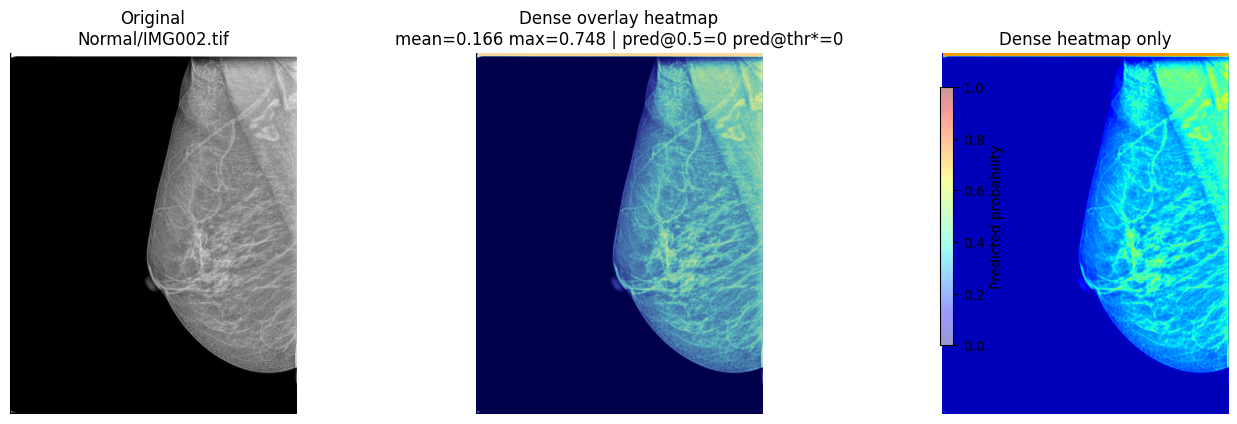

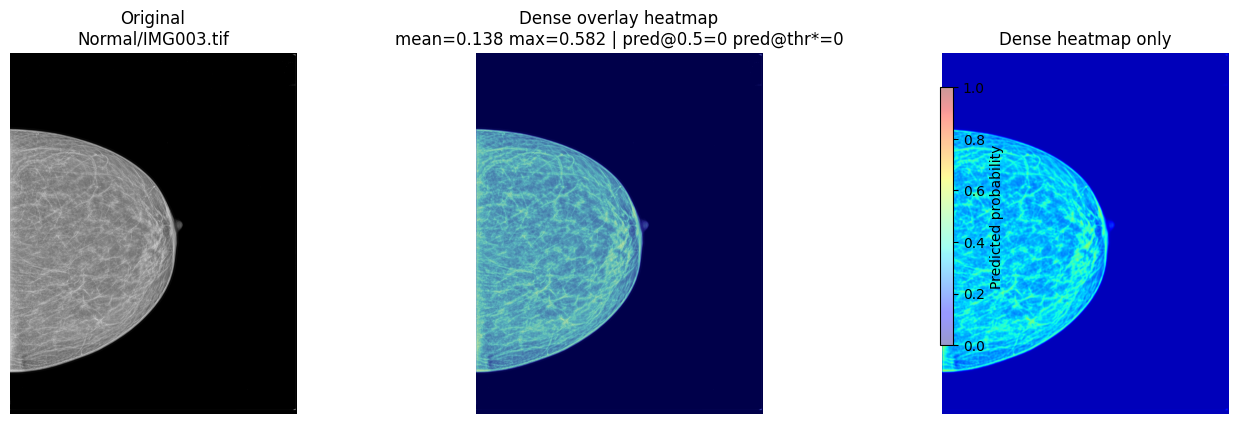

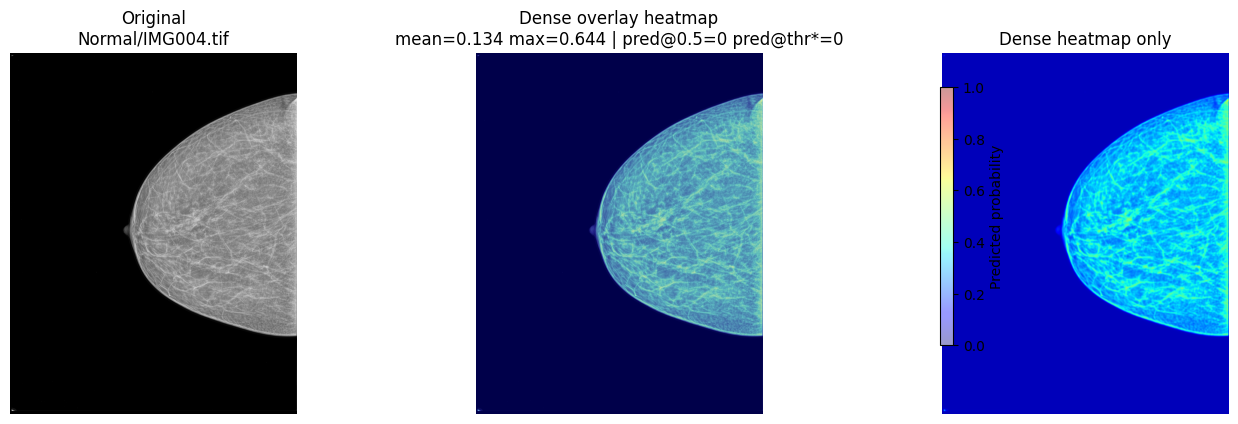

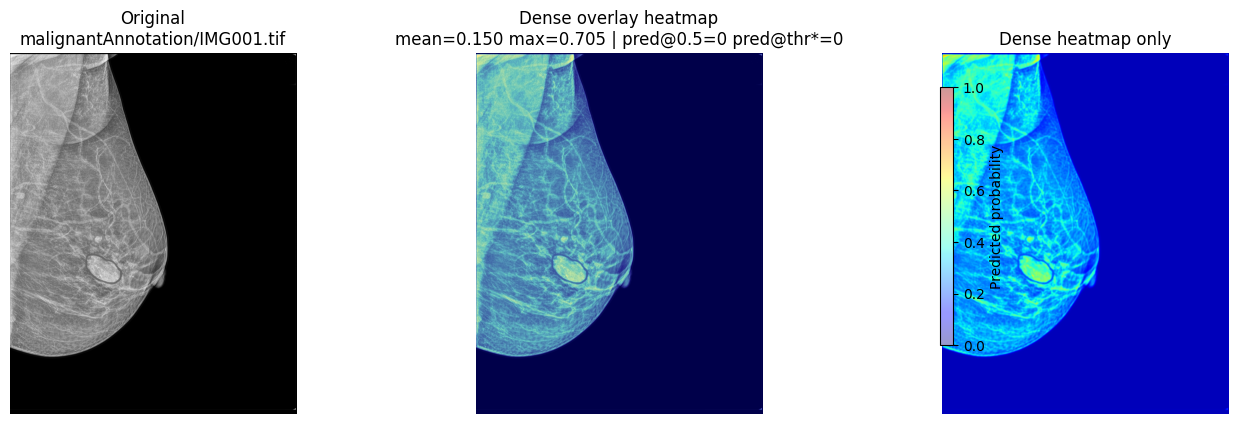

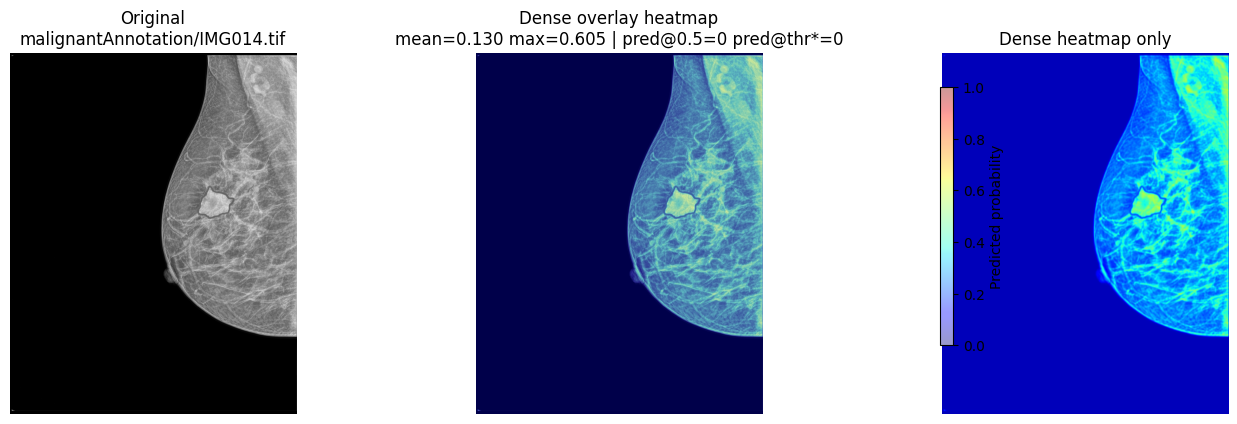

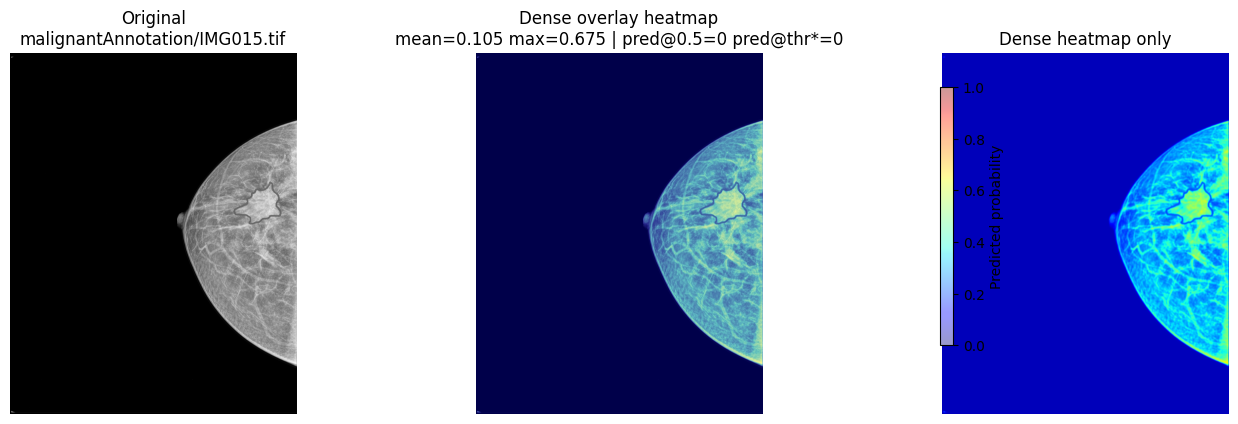

In [24]:
# -----------------------------
# Dense full-image inference + high-resolution localization heatmaps
# -----------------------------
from scipy.ndimage import gaussian_filter

# This block avoids patch-level square artifacts by scoring every spatial location.
# It reuses the same kernel mode (seed_ri or optimized) and same calibrated head logic.

DENSE_IMAGES_PER_FOLDER = images_per_folder
DENSE_SHOW = True
DENSE_SAVE_FIGS = False
DENSE_OVERLAY_ALPHA = 0.40
DENSE_INTERPOLATION = "bilinear"
DENSE_SMOOTH_SIGMA = 1.2  # set 0.0 to disable smoothing
KERNEL_FOR_INFERENCE = "optimized"  # or "optimized"


def _ensure_min_size(img_arr: np.ndarray, min_size: int):
    if img_arr.shape[0] >= min_size and img_arr.shape[1] >= min_size:
        return img_arr
    new_h = max(img_arr.shape[0], min_size)
    new_w = max(img_arr.shape[1], min_size)
    return np.array(
        Image.fromarray((img_arr * 255).astype(np.uint8)).resize((new_w, new_h), Image.BILINEAR),
        dtype=np.float32,
    ) / 255.0


def _get_dense_inference_params():
    if KERNEL_FOR_INFERENCE == "seed_ri":
        head = _fit_seed_head_if_needed()
        return {
            "kernel": seed_kernel_ri.astype(np.float32),
            "mode": "seed",
            "mu": float(head["mu"]),
            "sd": max(float(head["sd"]), 1e-8),
            "w": float(head["w"]),
            "b": float(head["b"]),
            "thr": float(head["thr"]),
        }

    return {
        "kernel": kernel_from_coeffs(coeffs, basis_t).detach().cpu().numpy().astype(np.float32),
        "mode": "optimized",
        "w": float(head_w.detach().cpu().item()),
        "b": float(head_b.detach().cpu().item()),
        "thr": float(globals().get("threshold_star", 0.5)),
    }


@torch.no_grad()
def dense_probability_map(img_arr: np.ndarray, params: dict):
    dev = torch.device(DEVICE)
    x_t = to_tensor_batch(img_arr[None, ...].astype(np.float32), torch.device("cpu"))
    if STANDARDIZE_PATCHES:
        x_t = patch_standardize(x_t)

    xb = x_t.to(dev, non_blocking=True)
    k_t = torch.from_numpy(params["kernel"]).to(dev)

    # Dense response map over full image (same kernel, no patch reduction).
    resp = F.conv2d(xb, k_t[None, None, :, :], padding=params["kernel"].shape[-1] // 2)[0, 0]
    feat = resp.abs()

    if params["mode"] == "seed":
        feat = (feat - params["mu"]) / params["sd"]

    logits = params["w"] * feat + params["b"]
    probs = torch.sigmoid(logits).detach().cpu().numpy().astype(np.float32)
    return probs


def _render_dense_result(img_path: Path, img_arr: np.ndarray, prob_map: np.ndarray, thr: float):
    vis_map = gaussian_filter(prob_map, sigma=float(DENSE_SMOOTH_SIGMA)) if DENSE_SMOOTH_SIGMA > 0 else prob_map

    score_mean = float(prob_map.mean())
    score_max = float(prob_map.max())
    pred_05 = int(score_mean > 0.5)
    pred_tuned = int(score_mean > thr)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
    axes[0].imshow(img_arr, cmap="gray")
    axes[0].set_title(f"Original\n{img_path.parent.name}/{img_path.name}")
    axes[0].axis("off")

    axes[1].imshow(img_arr, cmap="gray")
    im = axes[1].imshow(
        vis_map,
        cmap="jet",
        alpha=DENSE_OVERLAY_ALPHA,
        vmin=0.0,
        vmax=1.0,
        interpolation=DENSE_INTERPOLATION,
    )
    axes[1].set_title(
        "Dense overlay heatmap\n"
        f"mean={score_mean:.3f} max={score_max:.3f} | pred@0.5={pred_05} pred@thr*={pred_tuned}"
    )
    axes[1].axis("off")

    axes[2].imshow(vis_map, cmap="jet", vmin=0.0, vmax=1.0, interpolation=DENSE_INTERPOLATION)
    axes[2].set_title("Dense heatmap only")
    axes[2].axis("off")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.78)
    cbar.set_label("Predicted probability")

    plt.tight_layout()

    if DENSE_SAVE_FIGS:
        save_path = infer_out_dir / f"{img_path.stem}_radial_kernel_dense_heatmap_{KERNEL_FOR_INFERENCE}.png"
        plt.savefig(save_path, dpi=280, bbox_inches="tight")
        print(f"Saved: {save_path}")

    if DENSE_SHOW:
        plt.show()
    else:
        plt.close()


dense_paths = []
dense_paths.extend(_collect_image_paths(normal_dir, DENSE_IMAGES_PER_FOLDER))
dense_paths.extend(_collect_image_paths(ann_dir, DENSE_IMAGES_PER_FOLDER))
if len(dense_paths) == 0:
    raise RuntimeError("No inference images found for dense heatmap block.")

params = _get_dense_inference_params()
print(f"Running DENSE inference on {len(dense_paths)} image(s) with kernel mode={KERNEL_FOR_INFERENCE}; thr={params['thr']:.3f}")

for img_path in dense_paths:
    img_arr = _ensure_min_size(_load_gray_image(img_path), patch_size)
    prob_map = dense_probability_map(img_arr, params)
    _render_dense_result(img_path, img_arr, prob_map, params["thr"])


In [ ]:
# -----------------------------
# Save learned artifacts
# -----------------------------
np.save(OUT_DIR / "f_init.npy", f_init)
np.save(OUT_DIR / "f_optimized.npy", f_opt)
np.save(OUT_DIR / "kernel_seed_radial.npy", seed_kernel_from_f.astype(np.float32))
np.save(OUT_DIR / "kernel_optimized_radial.npy", k_opt.astype(np.float32))

summary = {
    "exp_dir": str(EXP_DIR),
    "kernel_path": str(kernel_path),
    "data_root": str(data_root),
    "train_split": TRAIN_SPLIT,
    "eval_split_used": eval_split_used,
    "resize_patch": RESIZE_PATCH,
    "response_mode": RESPONSE_MODE,
    "standardize_patches": bool(STANDARDIZE_PATCHES),
    "r_max_effective": int(r_eff),
    "f_init": [float(x) for x in f_init],
    "f_optimized": [float(x) for x in f_opt],
    "head_w": float(head_w.detach().cpu().item()),
    "head_b": float(head_b.detach().cpu().item()),
    "epochs": int(EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "lr_f": float(LR_F),
    "lr_head": float(LR_HEAD),
    "lambda_smooth": float(LAMBDA_SMOOTH),
    "lambda_anchor": float(LAMBDA_ANCHOR),
    "select_by": SELECT_BY,
    "tune_threshold": bool(TUNE_THRESHOLD),
    "threshold_star": float(threshold_star),
    "threshold_grid_size": int(THRESHOLD_GRID_SIZE),
    "history": history,
}

summary_path = OUT_DIR / "radial_fit_summary.json"
summary_path.write_text(json.dumps(summary, indent=2))

print("Saved:")
print(f"  {OUT_DIR / 'f_init.npy'}")
print(f"  {OUT_DIR / 'f_optimized.npy'}")
print(f"  {OUT_DIR / 'kernel_seed_radial.npy'}")
print(f"  {OUT_DIR / 'kernel_optimized_radial.npy'}")
print(f"  {summary_path}")
